Using device: cuda
🔽 Training on subset: 100000 samples
Training samples: 100000
Validation samples: 3989


Epoch 1/12: 100%|██████████████████████████████████████████████████████████████████| 3125/3125 [52:42<00:00,  1.01s/it]


Epoch 1 | Loss: 1.0299 | Val IoU: 0.1858
✅ Best model saved


Epoch 2/12: 100%|██████████████████████████████████████████████████████████████████| 3125/3125 [29:39<00:00,  1.76it/s]


Epoch 2 | Loss: 0.9119 | Val IoU: 0.2036
✅ Best model saved


...

Epoch 10 | Loss: 0.6339 | Val IoU: 0.2856


Epoch 11/12: 100%|█████████████████████████████████████████████████████████████████| 3125/3125 [29:40<00:00,  1.75it/s]


Epoch 11 | Loss: 0.6130 | Val IoU: 0.2939


Epoch 12/12: 100%|█████████████████████████████████████████████████████████████████| 3125/3125 [29:37<00:00,  1.76it/s]


Epoch 12 | Loss: 0.5916 | Val IoU: 0.3033
✅ Best model saved
🎉 Training complete


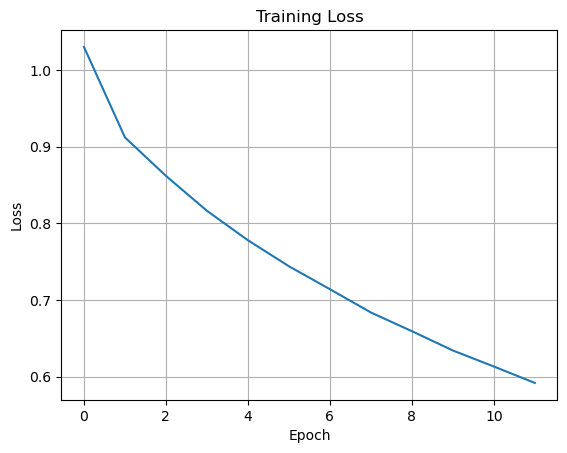

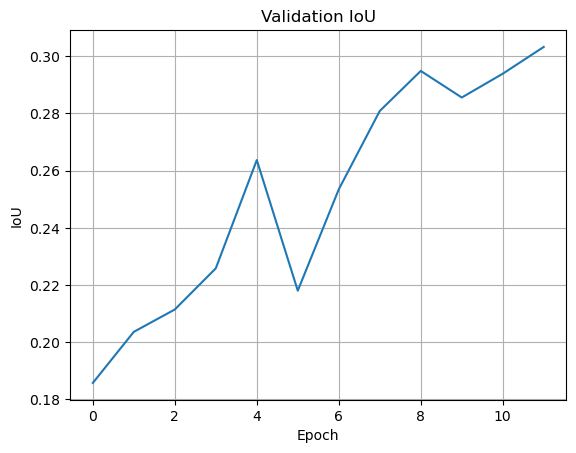

In [2]:
# ===============================
# FAST U-NET TRAINING (FINAL)
# ===============================

import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

# ===============================
# CONFIGURATION
# ===============================
DATASET_DIR = r"E:\processed_segmentation_dataset_224"
SAVE_DIR = r"E:\project\models"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32                 # 🔥 bigger batch
EPOCHS = 12                     # 🔥 fewer epochs
PATIENCE = 3
LR = 1e-4

MAX_TRAIN_SAMPLES = 100_000     # 🔥 LIMIT DATASET SIZE

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

torch.backends.cudnn.benchmark = True

# ===============================
# DATASET
# ===============================
class SegmentationDataset(Dataset):
    def __init__(self, root, split):
        self.image_dir = os.path.join(root, split, "images")
        self.mask_dir = os.path.join(root, split, "masks")
        self.images = sorted(os.listdir(self.image_dir))
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)
        mask = mask / 255.0

        image = self.transform(image)
        mask = torch.from_numpy(mask).float().unsqueeze(0)

        return image, mask

# ===============================
# LOAD DATASETS
# ===============================
full_train_ds = SegmentationDataset(DATASET_DIR, "train")
val_ds = SegmentationDataset(DATASET_DIR, "val")

# 🔥 SUBSAMPLE TRAINING DATA
if len(full_train_ds) > MAX_TRAIN_SAMPLES:
    indices = random.sample(range(len(full_train_ds)), MAX_TRAIN_SAMPLES)
    train_ds = Subset(full_train_ds, indices)
    print(f"🔽 Training on subset: {MAX_TRAIN_SAMPLES} samples")
else:
    train_ds = full_train_ds
    print(f"✅ Training on full dataset: {len(train_ds)} samples")

print("Training samples:", len(train_ds))
print("Validation samples:", len(val_ds))

# ===============================
# DATALOADERS (WINDOWS SAFE)
# ===============================
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,       # 🔥 IMPORTANT FOR WINDOWS
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# ===============================
# U-NET MODEL
# ===============================
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def CBR(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.enc1 = CBR(3, 64)
        self.enc2 = CBR(64, 128)
        self.enc3 = CBR(128, 256)
        self.enc4 = CBR(256, 512)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = CBR(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = CBR(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = CBR(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = CBR(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = CBR(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

model = UNet().to(DEVICE)

# ===============================
# LOSS, OPTIMIZER, AMP
# ===============================
bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler = GradScaler()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1.0
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

def iou_score(pred, target):
    pred = torch.sigmoid(pred) > 0.5
    intersection = (pred & target.bool()).float().sum()
    union = (pred | target.bool()).float().sum()
    return (intersection + 1e-6) / (union + 1e-6)

# ===============================
# TRAINING LOOP
# ===============================
best_iou = 0
epochs_no_improve = 0
train_losses, val_ious = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = bce(outputs, masks) + dice_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_iou = 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            val_iou += iou_score(model(imgs), masks)

    val_iou /= len(val_loader)
    val_ious.append(val_iou.item())

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Val IoU: {val_iou:.4f}")

    if val_iou > best_iou:
        best_iou = val_iou
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "tampering_unet_best.pth"))
        print("✅ Best model saved")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered")
        break

print("🎉 Training complete")

# ===============================
# PLOTS
# ===============================
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure()
plt.plot(val_ious)
plt.title("Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.grid()
plt.show()


In [3]:
# ===============================
# U-NET FINE-TUNING (LOW LR)
# ===============================

import os
import cv2
import torch
import random
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

# ===============================
# CONFIGURATION (FINE-TUNE)
# ===============================
DATASET_DIR = r"E:\processed_segmentation_dataset_224"
MODEL_PATH = r"E:\project\models\tampering_unet_best.pth"
SAVE_DIR = r"E:\project\models"

BATCH_SIZE = 32
FINE_TUNE_EPOCHS = 3          # 🔥 3–4 is enough
LR = 1e-5                    # 🔥 LOWER LR
MAX_TRAIN_SAMPLES = 100_000   # 🔥 SUBSET AGAIN

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

torch.backends.cudnn.benchmark = True

# ===============================
# DATASET (SAME AS TRAINING)
# ===============================
class SegmentationDataset(Dataset):
    def __init__(self, root, split):
        self.image_dir = os.path.join(root, split, "images")
        self.mask_dir = os.path.join(root, split, "masks")
        self.images = sorted(os.listdir(self.image_dir))
        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0) / 255.0

        image = self.transform(image)
        mask = torch.from_numpy(mask).float().unsqueeze(0)

        return image, mask

# ===============================
# LOAD + SUBSAMPLE TRAIN DATA
# ===============================
full_train_ds = SegmentationDataset(DATASET_DIR, "train")

if len(full_train_ds) > MAX_TRAIN_SAMPLES:
    indices = random.sample(range(len(full_train_ds)), MAX_TRAIN_SAMPLES)
    train_ds = Subset(full_train_ds, indices)
    print(f"🔽 Fine-tuning on subset: {MAX_TRAIN_SAMPLES} samples")
else:
    train_ds = full_train_ds
    print(f"✅ Fine-tuning on full dataset: {len(train_ds)} samples")

print("Fine-tuning samples:", len(train_ds))

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

# ===============================
# MODEL (LOAD BEST CHECKPOINT)
# ===============================
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def CBR(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.enc1 = CBR(3, 64)
        self.enc2 = CBR(64, 128)
        self.enc3 = CBR(128, 256)
        self.enc4 = CBR(256, 512)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = CBR(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = CBR(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = CBR(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = CBR(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = CBR(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

model = UNet().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH))
print("✅ Loaded best trained model")

# ===============================
# OPTIMIZER & LOSS
# ===============================
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
bce = nn.BCEWithLogitsLoss()
scaler = GradScaler()

def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1.0
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (
        pred.sum() + target.sum() + smooth
    )

# ===============================
# FINE-TUNING LOOP
# ===============================
for epoch in range(FINE_TUNE_EPOCHS):
    model.train()
    total_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Fine-tune Epoch {epoch+1}/{FINE_TUNE_EPOCHS}"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = bce(outputs, masks) + dice_loss(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Fine-tune Loss: {total_loss/len(train_loader):.4f}")

# ===============================
# SAVE FINE-TUNED MODEL
# ===============================
torch.save(
    model.state_dict(),
    os.path.join(SAVE_DIR, "tampering_unet_finetuned.pth")
)

print("🎉 Fine-tuning complete. Model saved.")


Using device: cuda
🔽 Fine-tuning on subset: 100000 samples
Fine-tuning samples: 100000
✅ Loaded best trained model


Fine-tune Epoch 1/3: 100%|█████████████████████████████████████████████████████████| 3125/3125 [51:32<00:00,  1.01it/s]


Epoch 1 | Fine-tune Loss: 0.5603


Fine-tune Epoch 2/3: 100%|█████████████████████████████████████████████████████████| 3125/3125 [30:14<00:00,  1.72it/s]


Epoch 2 | Fine-tune Loss: 0.5436


Fine-tune Epoch 3/3: 100%|█████████████████████████████████████████████████████████| 3125/3125 [30:15<00:00,  1.72it/s]

Epoch 3 | Fine-tune Loss: 0.5324
🎉 Fine-tuning complete. Model saved.


In [4]:
# ===============================
# MODEL EVALUATION (TEST SET)
# ===============================

test_ds = SegmentationDataset(DATASET_DIR, "test")
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

model.eval()

iou_list, dice_list, acc_list, prec_list, rec_list = [], [], [], [], []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Testing"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        preds = torch.sigmoid(model(imgs)) > 0.5

        TP = (preds & masks.bool()).float().sum()
        TN = ((~preds) & (~masks.bool())).float().sum()
        FP = (preds & (~masks.bool())).float().sum()
        FN = ((~preds) & masks.bool()).float().sum()

        iou = (TP + 1e-6) / (TP + FP + FN + 1e-6)
        dice = (2 * TP + 1e-6) / (2 * TP + FP + FN + 1e-6)
        accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
        precision = TP / (TP + FP + 1e-6)
        recall = TP / (TP + FN + 1e-6)

        iou_list.append(iou.item())
        dice_list.append(dice.item())
        acc_list.append(accuracy.item())
        prec_list.append(precision.item())
        rec_list.append(recall.item())

# ===============================
# FINAL RESULTS
# ===============================
print("\n📊 FINAL TEST PERFORMANCE")
print(f"IoU Score      : {np.mean(iou_list):.4f}")
print(f"Dice Coefficient: {np.mean(dice_list):.4f}")
print(f"Pixel Accuracy : {np.mean(acc_list):.4f}")
print(f"Precision      : {np.mean(prec_list):.4f}")
print(f"Recall         : {np.mean(rec_list):.4f}")


Testing: 100%|███████████████████████████████████████████████████████████████████████| 344/344 [02:25<00:00,  2.36it/s]


📊 FINAL TEST PERFORMANCE
IoU Score      : 0.3214
Dice Coefficient: 0.4256
Pixel Accuracy : 0.9535
Precision      : 0.4389
Recall         : 0.4258
